# Whitening Exploration
Trying to truly understand what is going on when Whitening is applied to a single session of the data.

In [1]:
import os
import h5py
from temporaldata import Data

import numpy as np

from matplotlib import pyplot as plt
from sklearn.decomposition import PCA

In [2]:
DATA_ROOT = "../data/processed/neurosoft_minipigs_2026"
RECORDING_ID = "sub-02_ses-01_task-AcousStim_acq-LH_desc-filtered"

path = os.path.join(DATA_ROOT, RECORDING_ID + ".h5")

with h5py.File(path) as f:
    data = Data.from_hdf5(f, lazy=False)

CHANNEL_NAMES = data.channels.id

In [3]:
# Get the intervals for each causal split and coalesce them to make them contiguous
train_intervals = data.splits.on_vs_off_causal_train.coalesce()
valid_intervals = data.splits.on_vs_off_causal_valid.coalesce()
test_intervals = data.splits.on_vs_off_causal_test.coalesce()

In [4]:
keep_channels = data.channels.type == "ecog"

channel_names = data.channels.id[keep_channels]

data_train = []
for interval in train_intervals:
    data_train.append(data.slice(interval[0], interval[1]).ecog.signal[:, keep_channels])

data_valid = []
for interval in valid_intervals:
    data_valid.append(data.slice(interval[0], interval[1]).ecog.signal[:, keep_channels])

data_test = []
for interval in test_intervals:
    data_test.append(data.slice(interval[0], interval[1]).ecog.signal[:, keep_channels])

Now, all the data from each split is in a list of numpy arrays. Each element of the list corresponds to a single recording. The data is all contiguous for one recording, but there are gaps between recordings.

### Some helpful functions

In [103]:
def plot_pca_variance(pca):
    plt.plot(pca.explained_variance_ratio_)
    plt.xlabel("Number of components")
    plt.ylabel("Explained variance ratio")
    plt.gca().set_ylim(0)
    plt.bar(range(len(pca.explained_variance_ratio_)), pca.explained_variance_ratio_)
    plt.show()

def plot_signal(signal, start=0, end=1, chann_names=CHANNEL_NAMES, fs=1000):
    """
    Plots the first `seconds` of all 24 channels with separate y locations (stacked traces), 
    keeping scaling consistent between all channels.

    Parameters:
    - signal: numpy array of shape (time, 24)
    - seconds: number of seconds to plot
    - fs: sampling rate in Hz (default 1000)
    """
    num_samples = int((end - start) * fs)
    start_sample = int(start * fs)
    end_sample = int(end * fs)
    t = (np.arange(num_samples) / fs) + start
    n_channels = signal.shape[1]
    data = signal[start_sample:end_sample, :]

    # Compute the global min/max for y-axis scaling
    y_min = np.min(data)
    y_max = np.max(data)
    y_range = y_max - y_min

    # Set spacing between traces
    offset = y_range * 0.25  # keeps traces apart

    plt.figure(figsize=(8, 0.25 * n_channels))
    for ch in range(n_channels):
        plt.plot(
            t,
            data[:, ch] + offset * ch,
            label=chann_names[ch],
            alpha=0.7,
        )

    plt.xlabel("Time (s)")
    plt.yticks(
        [offset * ch for ch in range(n_channels)],
        chann_names
    )
    plt.ylabel("Channel")
    plt.title(f"First {end - start} seconds of all 24 channels (stacked)")
    plt.tight_layout()
    plt.gca().set_xlim(start, end)
    plt.show()

def plot_covariance(cov_matrix):
    plt.figure(figsize=(5, 4))
    plt.imshow(cov_matrix, cmap='viridis', aspect='auto')
    plt.colorbar(label='Covariance')
    plt.xlabel('Channel Index')
    plt.ylabel('Channel Index')
    plt.title('Covariance Matrix')

### Data

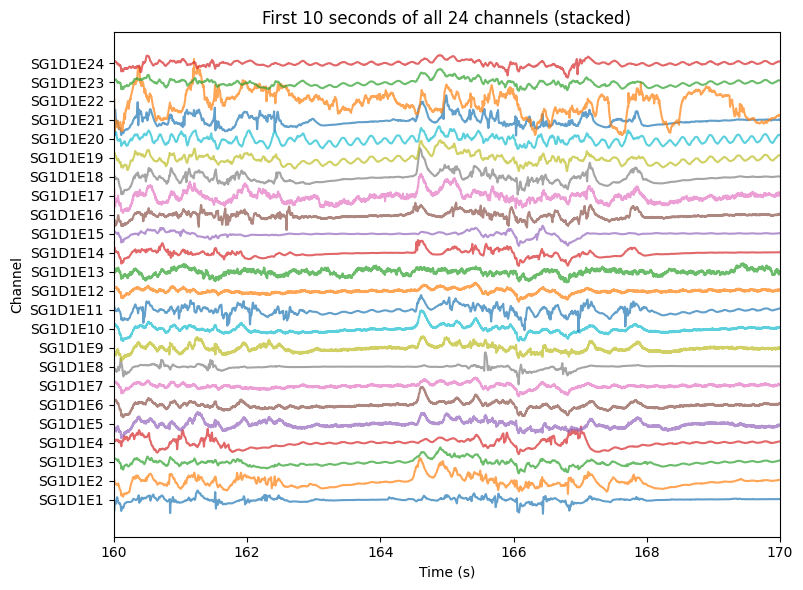

In [104]:
plot_signal(data_train[0], start=160, end=170, chann_names=channel_names)

### Exploration

Let's get the covariance matrix of the data:

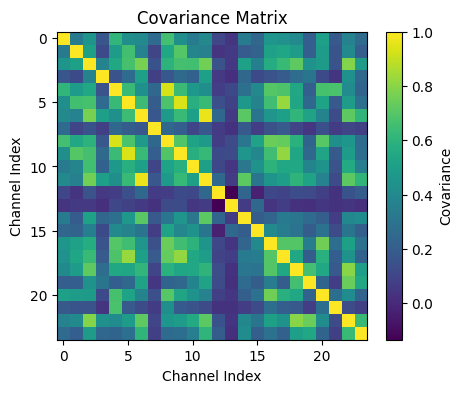

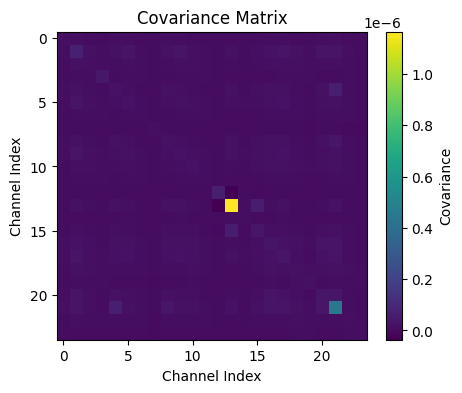

In [139]:
X = np.concatenate(data_train, axis=0)
X_norm = X / np.std(X, axis=0)
cov_normalized = np.cov(X_norm, rowvar=False)

plot_covariance(cov_normalized)

cov = np.cov(X, rowvar=False)
plot_covariance(cov)

We can see that the channels are quite highly correlated which is expected for Ecog data. We can also see that Channel 21 in the unnormalized data has a much higher variance than the other channels, which can be confirmed when looking at the data as this channel has higher amplitudes. It also looks like the Channel 12 has very little covariance with the other channels which again, can be confirmed when looking at the data.

#### Whitening:

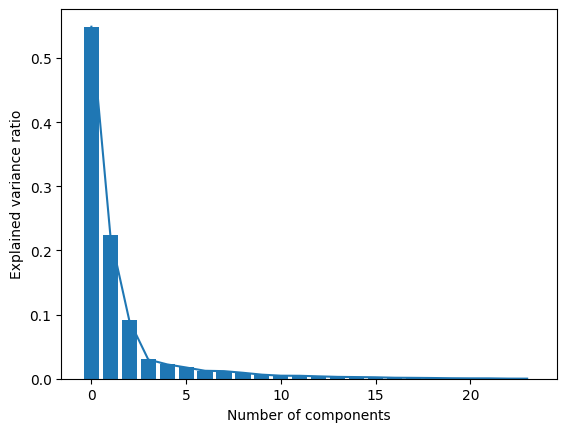

In [140]:
pca = PCA(whiten=True).fit(X)
X_proj = pca.transform(X)
plot_pca_variance(pca)

Here, we see that we clearly get an exponential decay in the explained variance ratio. This is expected for PCA whitening on the raw data because the data is highly correlated among channels.

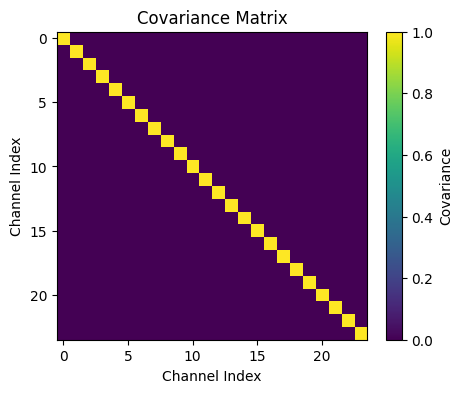

In [141]:
cov_proj = np.cov(X_proj, rowvar=False)
plot_covariance(cov_proj)

Now, the covariance is diagonal and the channels are correlated. We see that the variance is normalized to one because we are whitening. For normal PCA, the variance would not be normalized and would mostly be concentrated in the first few components:

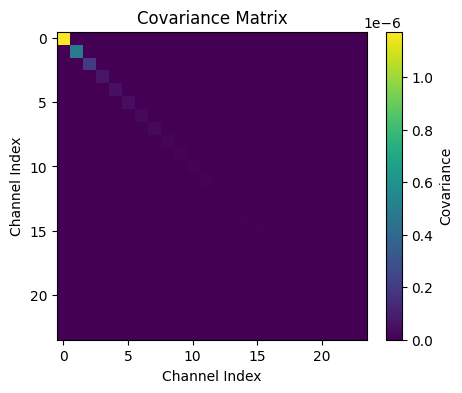

In [142]:
pca_nonorm = PCA(whiten=False).fit(X)
X_proj_nonorm = pca_nonorm.transform(X)
plot_covariance(np.cov(X_proj_nonorm, rowvar=False))

Now let's do the PCA on the data that has been whitened:

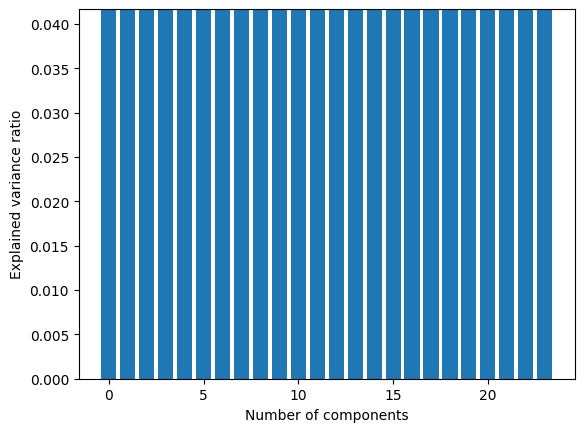

In [143]:
pca_after_whiten = PCA().fit(X_proj)
X_proj_after_whiten = pca_after_whiten.transform(X_proj)
plot_pca_variance(pca_after_whiten)

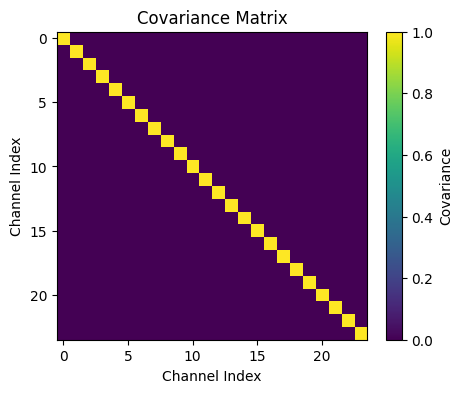

In [144]:
plot_covariance(np.cov(X_proj_after_whiten, rowvar=False))

As expected, we can see that the covariance is now the identity matrix. More importantly, we can see that each of the components are now explaining the exact same amount of variance, because by definition, the whitening process is the process of maximizing the variance of the components while keeping them uncorrelated.

### Animation

For fun, trying to animate the PCA timeseries in 2D:

In [145]:
import numpy as np
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def animate_pca_timeseries(data, interval=100):
    """
    Animates a 2D PCA timeseries.
    
    Parameters:
    - data: np.ndarray of shape (N, 2)
    - interval: delay between frames in milliseconds
    """
    n_frames = len(data)
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Set plot limits based on data range
    ax.set_xlim(data[:, 0].min() - 1, data[:, 0].max() + 1)
    ax.set_ylim(data[:, 1].min() - 1, data[:, 1].max() + 1)
    ax.set_title("PCA Timeseries Evolution")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

    # Initialize empty scatter plot
    # We use viridis (cmap) and map colors to the index of the point
    scat = ax.scatter([], [], c=[], cmap='viridis', vmin=0, vmax=n_frames, edgecolor='k', s=50)
    plt.colorbar(scat, label='Timepoint (Index)')

    def update(frame):
        # Update the positions: slice data up to the current frame
        scat.set_offsets(data[:frame+1])
        
        # Update colors: provide an array of indices for the colormap
        scat.set_array(np.arange(frame + 1))
        
        return scat,

    # Create the animation
    ani = FuncAnimation(fig, update, frames=n_frames, interval=interval, blit=True)
    
    # Close the plot to prevent a static ghost image from showing up
    plt.close()
    
    return HTML(ani.to_html5_video())


In [146]:
animate_pca_timeseries(X_proj[:1000, :2], interval=20)